# Parsing filtered_df.csv

In [ ]:
import pandas as pd
import numpy as np
import pathlib
import code.glmhmmt.paths as paths

In [144]:
paths.show_paths()  # Verificar que las rutas se han configurado correctamente
df = pd.read_parquet(paths.DATA_PATH/"predictions.parquet")
df2 = pd.read_parquet(paths.DATA_PATH/"df_filtered.parquet")

ROOT         = /Users/javierrodriguezmartinez/Documents/MAMME/TFM
CODE_DIR     = /Users/javierrodriguezmartinez/Documents/MAMME/TFM/code
DATA_PATH    = /Users/javierrodriguezmartinez/Documents/MAMME/TFM/data
FITTING_DIR  = /Users/javierrodriguezmartinez/Documents/MAMME/TFM/code/fitting
CSV_PATH     = /Users/javierrodriguezmartinez/Documents/MAMME/TFM/data/df_filtered.csv


Unique stimd_c in df: <ArrowStringArray>
['VG', 'SL', 'SM', 'SS']
Length: 4, dtype: str
Unique ttype_c in df: <ArrowStringArray>
['VG', 'DS', 'DM', 'DL']
Length: 4, dtype: str


,ttype_c,subject,correct_mean,model_mean
0,DL,A92,0.470621,0.549073
1,DM,A92,0.593711,0.591248
2,DS,A92,0.742178,0.646783
3,VG,A92,0.923640,0.899236


,stimd_c,subject,correct_mean,model_mean
0,SL,A92,0.830197,0.718806
1,SM,A92,0.739165,0.642116
2,SS,A92,0.578447,0.515021


,ttype_c,subject,correct_mean,model_mean
0,DL,A92,0.470621,0.549073
1,DM,A92,0.533889,0.518253
2,DS,A92,0.578447,0.515021


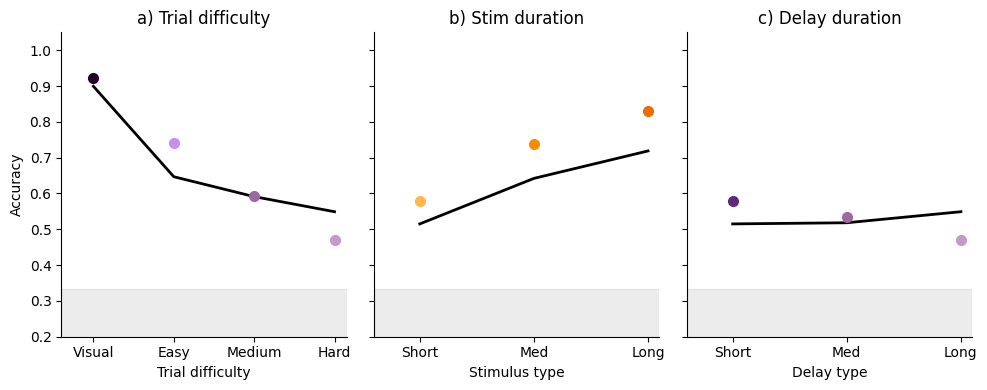

In [145]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import t

# -------------------------
# 0) Helper para guardar plots
# -------------------------
def get_plot_path(subfolder: str, fname: str, model_name: str) -> Path:
    out_dir = Path("results") / "plots" / model_name / subfolder
    out_dir.mkdir(parents=True, exist_ok=True)
    return out_dir / fname


# -------------------------
# 1) Construir columnas necesarias en df_predictions
# -------------------------
def prepare_predictions_df(df_pred: pd.DataFrame) -> pd.DataFrame:
    """
    Espera que df_pred tenga:
      - subject
      - response (0/1/2)
      - pL, pC, pR
      - performance (0/1 o bool)  -> para correct_bool
      - stimd_c y ttype_c (si no, intenta crearlas a partir de stimd_n/ttype_n)

    Devuelve df con:
      - correct_bool
      - p_model_correct
    """
    df = df_pred.copy()

    # correct_bool
    if "correct_bool" not in df.columns:
        if "performance" in df.columns:
            df["correct_bool"] = df["performance"].astype(int)
        else:
            raise ValueError("No encuentro 'performance' ni 'correct_bool' en df.")

    # Asegura pL,pC,pR
    for col in ["pL", "pC", "pR"]:
        if col not in df.columns:
            raise ValueError(f"Falta la columna '{col}' en df (predicciones por trial).")

    # p_model_correct = prob asignada a la respuesta observada
    # response debe ser 0/1/2
    if "response" not in df.columns:
        raise ValueError("Falta la columna 'response' (0/1/2) en df.")

    P = df[["pL", "pC", "pR"]].to_numpy()
    r = df["stimulus"].to_numpy().astype(int)

    # Control rápido por si hay -1, nan, etc.
    bad = ~np.isin(r, [0, 1, 2])
    if bad.any():
        raise ValueError(f"Hay responses fuera de {{0,1,2}} en filas: {np.where(bad)[0][:10]} ...")

    df["p_model_correct"] = P[np.arange(len(df)), r]

    # Si no tienes stimd_c / ttype_c, intenta crear desde stimd_n / ttype_n
    # (ajusta estos mappings a tu codificación real)
    if "stimd_c" not in df.columns:
        if "stimd_n" in df.columns:
            stim_map = {1: "SS", 2: "SM", 3: "SL", 4: "VG"}  # <-- AJUSTA si tu codificación es distinta
            df["stimd_c"] = df["stimd_n"].map(stim_map)
        else:
            raise ValueError("Falta 'stimd_c' y no existe 'stimd_n' para mapear.")

    if "ttype_c" not in df.columns:
        if "ttype_n" in df.columns:
            ttype_map = {0: "VG", 1: "DS", 2: "DM", 3: "DL"}  # <-- AJUSTA si tu codificación es distinta
            df["ttype_c"] = df["ttype_n"].map(ttype_map)
        else:
            raise ValueError("Falta 'ttype_c' y no existe 'ttype_n' para mapear.")

    return df


# -------------------------
# 2) Tus funciones de plotting (tal cual, solo las pego)
# -------------------------
def _plot_cat_panel(ax, df, group_col, order, title, xlabel, ylabel=None, palette=None, labels=None):
    df = df[df[group_col].isin(order)].copy()
    if df.empty:
        ax.set_visible(False)
        return

    subj = (
        df.groupby([group_col, "subject"], observed=True)
          .agg(correct_mean=("correct_bool", "mean"),
               model_mean=("p_model_correct", "mean"))
          .reset_index()
    )
    display(subj.head())  # Para verificar que el agrupamiento es correcto

    g = subj.groupby(group_col, observed=True)

    mean_data  = g["correct_mean"].mean()
    std_data   = g["correct_mean"].std(ddof=1)
    n_subj_d   = g["correct_mean"].count().clip(lower=1)
    sem_data   = std_data / np.sqrt(n_subj_d)

    mean_model = g["model_mean"].mean()
    std_model  = g["model_mean"].std(ddof=1)
    n_subj_m   = g["model_mean"].count().clip(lower=1)
    sem_model  = std_model / np.sqrt(n_subj_m)

    tcrit_d = t.ppf(0.975, n_subj_d - 1)
    tcrit_m = t.ppf(0.975, n_subj_m - 1)
    ci_data  = sem_data  * tcrit_d
    ci_model = sem_model * tcrit_m

    cats = [c for c in order if c in mean_data.index]
    x = np.arange(len(cats))

    md = mean_data.loc[cats].to_numpy()
    sd = ci_data.loc[cats].to_numpy()
    mm = mean_model.loc[cats].to_numpy()
    sm = ci_model.loc[cats].to_numpy()

    # Si quieres también poner el modelo como línea:
    ax.plot(x, mm, "-", color="black", lw=2, label="Model")
    ax.fill_between(x, mm-sm, mm+sm, color="black", alpha=0.12)

    colors = palette if palette else ["black"] * len(cats)
    for i, (xpos, yval, err) in enumerate(zip(x, md, sd)):
        ax.errorbar(xpos, yval, yerr=err, fmt="o",
                    color=colors[i], ms=7, capsize=3)

    ax.set_xticks(x)
    ax.set_xticklabels(labels if labels else cats)

    ax.set_ylim(0.2, 1.05)
    ax.axhspan(0, 1/3, color="gray", alpha=0.15)
    ax.set_xlim(left=-0.4)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    if ylabel:
        ax.set_ylabel(ylabel)


def plot_categorical_performance_all(df, model_name):
    fig, axes = plt.subplots(1, 3, figsize=(10, 4), sharey=True)
    ax1, ax2, ax3 = axes

    # a) Trial difficulty
    palette_a = ['#230027','#C88FEC','#9C69A3','#C698CB','#EFD9F5']
    labels_a  = ["Visual","Easy","Medium","Hard"]
    order_a   = ["VG","DS","DM","DL"]

    df_a = df.copy()
    print("Unique stimd_c in df:", df_a["stimd_c"].unique())
    print("Unique ttype_c in df:", df_a["ttype_c"].unique())
    _plot_cat_panel(ax1, df, "ttype_c", order_a,
                    title="a) Trial difficulty",
                    xlabel="Trial difficulty",
                    ylabel="Accuracy",
                    palette=palette_a, labels=labels_a)

    # b) Stim duration (solo DS, SS/SM/SL)
    palette_b = ["#FFB74D","#FB8C00","#EF6C00"]
    labels_b  = ['Short','Med','Long']
    order_b   = ["SS","SM","SL"]

    df_b = df[(df["ttype_c"] == "DS") & (df["stimd_c"].isin(order_b))]
    _plot_cat_panel(ax2, df_b, "stimd_c", order_b,
                    title="b) Stim duration",
                    xlabel="Stimulus type",
                    palette=palette_b, labels=labels_b)

    # c) Delay duration (solo SS)
    palette_c = ['#5E2A7E','#9C69A3','#C698CB']
    labels_c  = ['Short','Med','Long']
    order_c   = ["DS","DM","DL"]

    df_c = df[df["stimd_c"] == "SS"]
    _plot_cat_panel(ax3, df_c, "ttype_c", order_c,
                    title="c) Delay duration",
                    xlabel="Delay type",
                    palette=palette_c, labels=labels_c)

    sns.despine()
    fig.tight_layout()
    plt.show()



# -------------------------
# 3) USO (df_predictions -> plot)
# -------------------------
# df_predictions = ...  # tu df final con predicciones pL,pC,pR ya añadido por trial
# model_name = "glmhmm_K3_fixedA"  # pon el nombre que quieras

df_plot = prepare_predictions_df(df)
plot_categorical_performance_all(df_plot, model_name="glmhmm_K3_fixedA")